# Stage 1: Data Preparation and Preprocessing
Prepare a text dataset suitable for training a miniature language model.

In this level, we will:

1. Install and import the required libraries.
2. Load the WikiText-2 dataset.
3. Create a character-level tokenizer.
4. Convert text into token IDs.
5. Split the data into training and validation sets.
6. Create input-target sequences for next-token prediction.
7. Verify the data format and batch shapes.

### 1. Environment Setup

Install and import the libraries required for dataset preparation, numerical operations, and visualization. We will use PyTorch for the model implementation in later levels.

In [1]:
!pip -q install datasets

### 2. Import Libraries

Import the libraries used for dataset loading, text processing, tensor operations, and reproducibility. We also check whether a GPU is available in the Colab environment.

In [2]:
import random
import numpy as np
import torch

from datasets import load_dataset

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("PyTorch version:", torch.__version__)

Device: cuda
PyTorch version: 2.11.0+cu128


### 3. Load WikiText-2 Dataset

Load the raw WikiText-2 corpus using the Hugging Face Datasets library. We combine the training text into a single corpus while retaining the official validation split for evaluation.

Empty lines are removed to reduce unnecessary padding and whitespace.

In [4]:
dataset = load_dataset(
    "Salesforce/wikitext",
    "wikitext-2-raw-v1"
)

def clean_text(split):
    texts = [
        text.strip()
        for text in dataset[split]["text"]
        if text.strip()
    ]

    return "\n".join(texts)

train_text = clean_text("train")
val_text = clean_text("validation")

print("Training characters:", len(train_text))
print("Validation characters:", len(val_text))

print("\nSample text:\n")
print(train_text[:500])

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…): reconstructing file:   0%|          |  0.00B /  733kB            

wikitext-2-raw-v1/test-00000-of-00001.pa(…): downloading bytes:           |  0.00B            

wikitext-2-raw-v1/train-00000-of-00001.p(…): reconstructing file:   0%|          |  0.00B / 6.36MB            

wikitext-2-raw-v1/train-00000-of-00001.p(…): downloading bytes:           |  0.00B            

...

wikitext-2-raw-v1/validation-00000-of-00(…): downloading bytes:           |  0.00B            

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Training characters: 10845452
Validation characters: 1137224

Sample text:

= Valkyria Chronicles III =
Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs paral


### 4. Character-Level Tokenization

Create a vocabulary containing the unique characters found in the training and validation text. Each character is assigned an integer ID, allowing the text to be represented as a sequence of numerical tokens.

The tokenizer will provide two operations: encoding text into token IDs and decoding token IDs back into text.

In [5]:
# Build vocabulary from both splits
# Including validation characters prevents unknown-character
# errors during evaluation.

vocab = sorted(set(train_text + val_text))

vocab_size = len(vocab)

stoi = {ch: i for i, ch in enumerate(vocab)}
itos = {i: ch for i, ch in enumerate(vocab)}

def encode(text):
    return [stoi[ch] for ch in text]

def decode(tokens):
    return "".join(itos[token] for token in tokens)

print("Vocabulary size:", vocab_size)

sample = train_text[:100]

encoded_sample = encode(sample)
decoded_sample = decode(encoded_sample)

print("\nOriginal:")
print(sample)

print("\nDecoded:")
print(decoded_sample)

assert sample == decoded_sample
print("\nTokenizer verification passed.")

Vocabulary size: 1118

Original:
= Valkyria Chronicles III =
Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , l

Decoded:
= Valkyria Chronicles III =
Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , l

Tokenizer verification passed.


### 5. Convert Text into Token Tensors

Convert the training and validation corpora into PyTorch tensors containing integer token IDs. These tensors will be used to construct fixed-length sequences for model training.

In [6]:
train_data = torch.tensor(
    encode(train_text),
    dtype=torch.long
)

val_data = torch.tensor(
    encode(val_text),
    dtype=torch.long
)

print("Train tensor shape:", train_data.shape)
print("Validation tensor shape:", val_data.shape)

print("Data type:", train_data.dtype)

Train tensor shape: torch.Size([10845452])
Validation tensor shape: torch.Size([1137224])
Data type: torch.int64


### 6. Construct Training Sequences

Create fixed-length input and target sequences for causal language modeling.

The input sequence contains tokens from the corpus, while the target sequence is shifted by one position. The model will learn to predict the next character for every position in the input.

For example, given the sequence `hello`, the model learns to predict the next character at each position using the preceding context.

In [7]:
CONTEXT_LENGTH = 128

def get_batch_data(data, context_length):
    """
    Create a single randomly sampled input-target sequence.
    """

    start = torch.randint(
        0,
        len(data) - context_length - 1,
        (1,)
    ).item()

    x = data[start : start + context_length]

    y = data[start + 1 : start + context_length + 1]

    return x, y


x_sample, y_sample = get_batch_data(
    train_data,
    CONTEXT_LENGTH
)

print("Input shape:", x_sample.shape)
print("Target shape:", y_sample.shape)

print("\nInput text:")
print(decode(x_sample.tolist()))

print("\nTarget text:")
print(decode(y_sample.tolist()))

Input shape: torch.Size([128])
Target shape: torch.Size([128])

Input text:
, with the highest traffic count being just over 400 vehicles daily , at its intersection with the Seward Highway . The daily av

Target text:
 with the highest traffic count being just over 400 vehicles daily , at its intersection with the Seward Highway . The daily ave


### 7. Mini-Batch Generation

Define a batch sampling function that randomly selects multiple sequences from the training or validation corpus.

Each batch contains input and target tensors of shape `(batch_size, context_length)`. The target sequence is shifted by one token relative to the input sequence.

In [8]:
BATCH_SIZE = 32

def get_batch(data, batch_size, context_length):
    """
    Generate a batch of input-target sequences.
    """

    starts = torch.randint(
        0,
        len(data) - context_length - 1,
        (batch_size,)
    )

    x = torch.stack([
        data[start : start + context_length]
        for start in starts
    ])

    y = torch.stack([
        data[start + 1 : start + context_length + 1]
        for start in starts
    ])

    return x.to(device), y.to(device)


x_batch, y_batch = get_batch(
    train_data,
    BATCH_SIZE,
    CONTEXT_LENGTH
)

print("Input batch shape:", x_batch.shape)
print("Target batch shape:", y_batch.shape)

print("Input device:", x_batch.device)
print("Target device:", y_batch.device)

Input batch shape: torch.Size([32, 128])
Target batch shape: torch.Size([32, 128])
Input device: cuda:0
Target device: cuda:0


### 8. Data Pipeline Verification

Verify that the generated batches have the expected shapes, data types, and next-token alignment.

The input and target sequences should differ by one character in their original corpus positions. These checks confirm that the preprocessing pipeline is ready for model implementation.

In [9]:
assert x_batch.shape == (BATCH_SIZE, CONTEXT_LENGTH)
assert y_batch.shape == (BATCH_SIZE, CONTEXT_LENGTH)

assert x_batch.dtype == torch.long
assert y_batch.dtype == torch.long

# Verify next-token alignment for the first sequence
assert torch.equal(
    x_batch[0, 1:],
    y_batch[0, :-1]
)

print("All preprocessing checks passed.")

All preprocessing checks passed.


### Stage 2: Baseline Transformer Architecture

We will implement a small decoder-only Transformer language model.

The model predicts the next character in a sequence using causal self-attention. Causal masking ensures that each token can only attend to itself and preceding tokens, preventing the model from accessing future information.

This baseline uses learned token and positional embeddings. Rotary Position Embeddings will be introduced in later levels so that we can compare the standard positional representation with RoPE.

The architecture consists of:
- Token embeddings
- Learned positional embeddings
- Multi-head causal self-attention
- Feed-forward network
- Residual connections
- Layer normalization
- Output projection to vocabulary logits

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [11]:
# Model configuration
VOCAB_SIZE = len(stoi)

D_MODEL = 128
N_HEADS = 4
N_LAYERS = 3

DROPOUT = 0.1
CONTEXT_LENGTH = 128

assert D_MODEL % N_HEADS == 0

HEAD_DIM = D_MODEL // N_HEADS

print("Vocabulary size:", VOCAB_SIZE)
print("Model dimension:", D_MODEL)
print("Number of attention heads:", N_HEADS)
print("Head dimension:", HEAD_DIM)
print("Number of layers:", N_LAYERS)

Vocabulary size: 1118
Model dimension: 128
Number of attention heads: 4
Head dimension: 32
Number of layers: 3


### 9. Multi-Head Causal Self-Attention

Self-attention allows each token to gather information from other tokens in the sequence.

For each token, we compute:
- Query (Q)
- Key (K)
- Value (V)

The attention scores are calculated using the query-key dot product:

Attention(Q, K, V) = softmax(QKᵀ / √dₖ)V

A causal mask is applied before softmax so that a token cannot attend to future tokens.

Multi-head attention divides the model representation into multiple smaller attention heads. Each head can learn different relationships between tokens.

In [12]:
class CausalSelfAttention(nn.Module):
    def __init__(
        self,
        d_model,
        n_heads,
        context_length,
        dropout=0.1
    ):
        super().__init__()

        assert d_model % n_heads == 0

        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

        self.qkv_projection = nn.Linear(d_model, 3 * d_model)
        self.output_projection = nn.Linear(d_model, d_model)

        self.attention_dropout = nn.Dropout(dropout)
        self.output_dropout = nn.Dropout(dropout)

        # Lower triangular causal mask
        causal_mask = torch.tril(
            torch.ones(context_length, context_length)
        )

        self.register_buffer(
            "causal_mask",
            causal_mask
        )

    def forward(self, x):
        batch_size, sequence_length, _ = x.shape

        # Shape: [B, T, 3 * D]
        qkv = self.qkv_projection(x)

        # Split into query, key, and value
        q, k, v = qkv.chunk(3, dim=-1)

        # Reshape:
        # [B, T, D] -> [B, H, T, head_dim]
        q = q.view(
            batch_size,
            sequence_length,
            self.n_heads,
            self.head_dim
        ).transpose(1, 2)

        k = k.view(
            batch_size,
            sequence_length,
            self.n_heads,
            self.head_dim
        ).transpose(1, 2)

        v = v.view(
            batch_size,
            sequence_length,
            self.n_heads,
            self.head_dim
        ).transpose(1, 2)

        # Attention scores: [B, H, T, T]
        attention_scores = (
            q @ k.transpose(-2, -1)
        ) / (self.head_dim ** 0.5)

        # Apply causal mask
        mask = self.causal_mask[:sequence_length, :sequence_length]

        attention_scores = attention_scores.masked_fill(
            mask == 0,
            float("-inf")
        )

        # Convert scores into probabilities
        attention_weights = F.softmax(
            attention_scores,
            dim=-1
        )

        attention_weights = self.attention_dropout(
            attention_weights
        )

        # Weighted sum of values
        output = attention_weights @ v

        # [B, H, T, head_dim] -> [B, T, D]
        output = output.transpose(1, 2).contiguous()

        output = output.view(
            batch_size,
            sequence_length,
            self.d_model
        )

        output = self.output_projection(output)
        output = self.output_dropout(output)

        return output

### 10. Feed-Forward Network

The feed-forward network processes each token representation independently after the attention operation.

It consists of:
1. A linear projection that expands the representation.
2. A GELU activation function.
3. A linear projection that returns the representation to the original dimension.

The expansion allows the model to learn more complex transformations of the information gathered through attention.

In [13]:
class FeedForward(nn.Module):
    def __init__(self, d_model, dropout=0.1):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.network(x)

### 11. Transformer Block

A Transformer block combines self-attention and the feed-forward network.

Each sublayer uses:
- Layer normalization
- A residual connection

The residual connection adds the input of a sublayer to its output. This helps preserve information and supports stable optimization in deeper networks.

We use pre-layer normalization:

`x = x + Attention(LayerNorm(x))`

`x = x + FeedForward(LayerNorm(x))`

In [14]:
class TransformerBlock(nn.Module):
    def __init__(
        self,
        d_model,
        n_heads,
        context_length,
        dropout=0.1
    ):
        super().__init__()

        self.layer_norm_1 = nn.LayerNorm(d_model)
        self.layer_norm_2 = nn.LayerNorm(d_model)

        self.attention = CausalSelfAttention(
            d_model=d_model,
            n_heads=n_heads,
            context_length=context_length,
            dropout=dropout
        )

        self.feed_forward = FeedForward(
            d_model=d_model,
            dropout=dropout
        )

    def forward(self, x):
        # Attention sublayer with residual connection
        x = x + self.attention(
            self.layer_norm_1(x)
        )

        # Feed-forward sublayer with residual connection
        x = x + self.feed_forward(
            self.layer_norm_2(x)
        )

        return x

### 12. Complete Language Model

The complete model contains:

1. Token embedding layer
2. Learned positional embedding layer
3. A stack of Transformer blocks
4. Final layer normalization
5. Linear output projection

The output of the model is a set of logits for every token position in the vocabulary.

Output shape:

`[batch_size, sequence_length, vocabulary_size]`

These logits will later be used with cross-entropy loss for next-token prediction.

In [15]:
class MiniTransformerLM(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model,
        n_heads,
        n_layers,
        context_length,
        dropout=0.1
    ):
        super().__init__()

        self.context_length = context_length
        self.d_model = d_model

        self.token_embedding = nn.Embedding(
            vocab_size,
            d_model
        )

        self.position_embedding = nn.Embedding(
            context_length,
            d_model
        )

        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(
                d_model=d_model,
                n_heads=n_heads,
                context_length=context_length,
                dropout=dropout
            )
            for _ in range(n_layers)
        ])

        self.final_layer_norm = nn.LayerNorm(d_model)

        self.output_projection = nn.Linear(
            d_model,
            vocab_size,
            bias=False
        )

    def forward(self, input_ids):
        batch_size, sequence_length = input_ids.shape

        assert sequence_length <= self.context_length

        # Create position indices
        positions = torch.arange(
            sequence_length,
            device=input_ids.device
        )

        # Token and positional embeddings
        token_embeddings = self.token_embedding(input_ids)
        position_embeddings = self.position_embedding(positions)

        x = token_embeddings + position_embeddings

        # Pass through Transformer blocks
        for block in self.transformer_blocks:
            x = block(x)

        # Final normalization
        x = self.final_layer_norm(x)

        # Convert hidden states to vocabulary logits
        logits = self.output_projection(x)

        return logits

### 13. Model Initialization

We now initialize the baseline Transformer using the vocabulary created during Level 1.

The model is moved to the available device, which will usually be a GPU in Google Colab.

We also calculate the number of trainable parameters to understand the model's size.

In [16]:
model = MiniTransformerLM(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    context_length=CONTEXT_LENGTH,
    dropout=DROPOUT
).to(device)

In [17]:
total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f"Trainable parameters: {total_parameters:,}")
print(f"Model device: {device}")

Trainable parameters: 897,664
Model device: cuda


### 14. Forward Pass Verification

Before training the model, we verify that the forward pass works correctly.

We generate a small batch of token sequences and pass them through the model.

The expected output shape is:

`[batch_size, sequence_length, vocabulary_size]`

The model should produce one vocabulary distribution for every token position in every sequence.

In [18]:
X, Y = get_batch(
    train_data,
    batch_size=4,
    context_length=CONTEXT_LENGTH
)

with torch.no_grad():
    logits = model(X)

print("Input shape:", X.shape)
print("Target shape:", Y.shape)
print("Logits shape:", logits.shape)

assert X.shape == (
    4,
    CONTEXT_LENGTH
)

assert Y.shape == (
    4,
    CONTEXT_LENGTH
)

assert logits.shape == (
    4,
    CONTEXT_LENGTH,
    VOCAB_SIZE
)

print("Forward pass verification successful.")

Input shape: torch.Size([4, 128])
Target shape: torch.Size([4, 128])
Logits shape: torch.Size([4, 128, 1118])
Forward pass verification successful.


### 15. Inspecting the Output

The model currently has randomly initialized weights, so its predictions are not meaningful.

We inspect the logits at the first sequence position and identify the token with the highest score.

This is only a structural verification. Meaningful predictions will be evaluated after the training loop is implemented.

In [19]:
first_position_logits = logits[0, 0]

predicted_token_id = torch.argmax(
    first_position_logits
).item()

print("Predicted token ID:", predicted_token_id)
print("Predicted character:", repr(itos[predicted_token_id]))

Predicted token ID: 294
Predicted character: 'У'


## Stage 3: Rotary Position Embedding

Rotary Position Embedding (RoPE) represents positional information by rotating pairs of elements in a vector.

For a vector with an even number of dimensions, RoPE divides the vector into pairs:

(x₁, x₂), (x₃, x₄), ...

Each pair is rotated by a position-dependent angle.

The rotation is implemented using sine and cosine values rather than explicitly constructing a rotation matrix. This provides a computationally efficient implementation.

At this stage, we will implement and test RoPE independently. It will be integrated into the query and key representations of self-attention in Level 4.

### 16. RoPE Rotation

For each pair of values, a two-dimensional rotation is applied:

`x'₁ = x₁ cos(θ) - x₂ sin(θ)`

`x'₂ = x₁ sin(θ) + x₂ cos(θ)`

The angle depends on the token position and the frequency associated with the pair of dimensions.

The embedding dimension of each attention head must be even because the dimensions are processed in pairs.

In [20]:
# RoPE operates on the attention head dimension
assert HEAD_DIM % 2 == 0, (
    "RoPE requires an even attention head dimension."
)

print("Attention head dimension:", HEAD_DIM)
print("Number of rotated pairs:", HEAD_DIM // 2)

Attention head dimension: 32
Number of rotated pairs: 16


### 17. Inverse Frequencies

RoPE uses a different rotation frequency for each pair of dimensions.

The inverse frequency is calculated using:

`θᵢ = 10000^(-2i / d)`

where:

- `i` represents the dimension-pair index.
- `d` represents the attention head dimension.

Lower-indexed pairs rotate faster, while higher-indexed pairs rotate more slowly.

We will store these inverse frequencies as a buffer so they are moved automatically to the appropriate device with the model.

In [21]:
def get_inverse_frequencies(head_dim, base=10000.0):
    assert head_dim % 2 == 0

    pair_indices = torch.arange(
        0,
        head_dim,
        2,
        dtype=torch.float32
    )

    inverse_frequencies = 1.0 / (
        base ** (pair_indices / head_dim)
    )

    return inverse_frequencies

In [22]:
inverse_frequencies = get_inverse_frequencies(
    head_dim=HEAD_DIM
)

print("Inverse frequency shape:", inverse_frequencies.shape)
print("Inverse frequencies:", inverse_frequencies)

assert inverse_frequencies.shape == (
    HEAD_DIM // 2,
)

Inverse frequency shape: torch.Size([16])
Inverse frequencies: tensor([1.0000e+00, 5.6234e-01, 3.1623e-01, 1.7783e-01, 1.0000e-01, 5.6234e-02,
        3.1623e-02, 1.7783e-02, 1.0000e-02, 5.6234e-03, 3.1623e-03, 1.7783e-03,
        1.0000e-03, 5.6234e-04, 3.1623e-04, 1.7783e-04])


### 18. Position-Dependent Rotation Angles

Each token position is assigned a set of rotation angles.

The angles are calculated by multiplying the token positions by the inverse frequencies:

`angles = position × inverse_frequency`

For a sequence of length T, the resulting angle tensor has the shape:

`[T, head_dim / 2]`

We will then calculate the cosine and sine values for each angle.

In [23]:
def build_rope_cache(
    context_length,
    head_dim,
    base=10000.0,
    device=None
):
    assert head_dim % 2 == 0

    inverse_frequencies = get_inverse_frequencies(
        head_dim=head_dim,
        base=base
    ).to(device)

    positions = torch.arange(
        context_length,
        dtype=torch.float32,
        device=device
    )

    # Shape: [T, head_dim / 2]
    angles = torch.outer(
        positions,
        inverse_frequencies
    )

    cos_values = torch.cos(angles)
    sin_values = torch.sin(angles)

    return cos_values, sin_values

In [24]:
cos_values, sin_values = build_rope_cache(
    context_length=CONTEXT_LENGTH,
    head_dim=HEAD_DIM,
    device=device
)

print("Cosine cache shape:", cos_values.shape)
print("Sine cache shape:", sin_values.shape)

assert cos_values.shape == (
    CONTEXT_LENGTH,
    HEAD_DIM // 2
)

assert sin_values.shape == (
    CONTEXT_LENGTH,
    HEAD_DIM // 2
)

Cosine cache shape: torch.Size([128, 16])
Sine cache shape: torch.Size([128, 16])


### 19. Efficient Pairwise Rotation

Instead of constructing a complete rotation matrix, we can rotate the vector using pairs of values.

For a tensor with shape:

[B, H, T, head_dim]

we separate the even and odd dimensions:

- Even dimensions: x₁, x₃, x₅, ...
- Odd dimensions: x₂, x₄, x₆, ...

The rotation is then applied using the cosine and sine caches.

The cosine and sine values are expanded across the batch and attention-head dimensions using broadcasting.

In [25]:
def rotate_half(x):
    """
    Splits the last dimension into pairs and rotates each pair
    by 90 degrees:

    [x1, x2] -> [-x2, x1]
    """

    x_even = x[..., ::2]
    x_odd = x[..., 1::2]

    rotated = torch.stack(
        (-x_odd, x_even),
        dim=-1
    )

    return rotated.flatten(start_dim=-2)

In [26]:
def apply_rope(
    x,
    cos_values,
    sin_values
):
    """
    Applies Rotary Position Embedding to x.

    x shape:
        [B, H, T, head_dim]

    cos_values and sin_values shape:
        [T, head_dim / 2]
    """

    batch_size, n_heads, sequence_length, head_dim = x.shape

    assert head_dim % 2 == 0

    # Expand each value across the paired dimensions
    cos = torch.repeat_interleave(
        cos_values[:sequence_length],
        repeats=2,
        dim=-1
    )

    sin = torch.repeat_interleave(
        sin_values[:sequence_length],
        repeats=2,
        dim=-1
    )

    # Shape: [1, 1, T, head_dim]
    cos = cos.unsqueeze(0).unsqueeze(0)
    sin = sin.unsqueeze(0).unsqueeze(0)

    rotated_x = (
        x * cos
        + rotate_half(x) * sin
    )

    return rotated_x

### 20. RoPE Rotation Verification

We will now test the implementation using a randomly generated tensor.

The input represents query or key vectors with the shape:

`[batch_size, number_of_heads, sequence_length, head_dim]`

The output must have exactly the same shape as the input.

We will also verify that the rotation at position zero does not change the original vector because its rotation angle is zero.

In [27]:
test_batch_size = 2
test_heads = N_HEADS
test_sequence_length = 16

test_x = torch.randn(
    test_batch_size,
    test_heads,
    test_sequence_length,
    HEAD_DIM,
    device=device
)

test_cos, test_sin = build_rope_cache(
    context_length=CONTEXT_LENGTH,
    head_dim=HEAD_DIM,
    device=device
)

rotated_x = apply_rope(
    x=test_x,
    cos_values=test_cos,
    sin_values=test_sin
)

print("Input shape:", test_x.shape)
print("Output shape:", rotated_x.shape)

assert rotated_x.shape == test_x.shape

print("RoPE shape verification successful.")

Input shape: torch.Size([2, 4, 16, 32])
Output shape: torch.Size([2, 4, 16, 32])
RoPE shape verification successful.


### 21. Position Zero Verification

At position zero, all rotation angles are zero.

Therefore:

`cos(0) = 1`

`sin(0) = 0`

The rotated vector at position zero should be equal to the original vector, apart from negligible floating-point differences.

In [28]:
original_position_zero = test_x[:, :, 0, :]
rotated_position_zero = rotated_x[:, :, 0, :]

position_zero_difference = torch.max(
    torch.abs(
        original_position_zero - rotated_position_zero
    )
).item()

print(
    "Maximum difference at position zero:",
    position_zero_difference
)

assert torch.allclose(
    original_position_zero,
    rotated_position_zero,
    atol=1e-6
)

print("Position zero verification successful.")

Maximum difference at position zero: 0.0
Position zero verification successful.


### 22. Rotation Norm Verification

A rotation preserves the Euclidean norm of a vector.

Therefore, applying RoPE should preserve the norm of each pair of dimensions, subject to small floating-point errors.

This test verifies that the implementation behaves like a rotation rather than changing the magnitude of the vector.

In [29]:
original_norms = torch.linalg.vector_norm(
    test_x,
    dim=-1
)

rotated_norms = torch.linalg.vector_norm(
    rotated_x,
    dim=-1
)

maximum_norm_difference = torch.max(
    torch.abs(original_norms - rotated_norms)
).item()

print(
    "Maximum norm difference:",
    maximum_norm_difference
)

assert torch.allclose(
    original_norms,
    rotated_norms,
    atol=1e-5
)

print("Norm preservation verification successful.")

Maximum norm difference: 4.76837158203125e-07
Norm preservation verification successful.


### 23. Visualizing a Single Pair Rotation Numerically

To understand the effect of RoPE, we will inspect the first pair of dimensions for one token.

The rotation angle depends on the token position. Consequently, the same input vector can produce different rotated representations at different positions.

The following cell compares the original and rotated values for the first dimension pair.

In [30]:
sample_x = torch.tensor(
    [[[
        [1.0, 0.0] + [0.0] * (HEAD_DIM - 2)
    ]]],
    device=device
)

sample_x = sample_x.expand(
    1,
    1,
    4,
    HEAD_DIM
).clone()

sample_cos, sample_sin = build_rope_cache(
    context_length=4,
    head_dim=HEAD_DIM,
    device=device
)

sample_rotated = apply_rope(
    sample_x,
    sample_cos,
    sample_sin
)

for position in range(4):
    print(
        f"Position {position}:",
        sample_rotated[0, 0, position, :2].detach().cpu()
    )

Position 0: tensor([1., 0.])
Position 1: tensor([0.5403, 0.8415])
Position 2: tensor([-0.4161,  0.9093])
Position 3: tensor([-0.9900,  0.1411])


## Stage 4: Integrating RoPE into Self-Attention

In the baseline Transformer, positional information is introduced by adding learned positional embeddings to token embeddings.

In the RoPE-based model, we will remove the learned positional embeddings and instead rotate the query and key representations inside each attention layer.

The integration process is:

1. Generate query, key, and value projections.
2. Reshape them into multiple attention heads.
3. Apply RoPE to the query and key tensors.
4. Calculate scaled dot-product attention.
5. Apply the causal mask.
6. Combine the attention outputs.

Values are not rotated.

This allows us to isolate the effect of RoPE while keeping the remaining model architecture unchanged.

### 24. RoPE-Enabled Causal Self-Attention

The baseline attention implementation already produces query, key, and value tensors with the shape:

`[B, H, T, head_dim]`

We will apply the RoPE transformation to the query and key tensors after reshaping them and before calculating the attention scores.

The cosine and sine caches are created once for the maximum context length and reused during the forward pass.

In [31]:
class RoPECausalSelfAttention(nn.Module):
    def __init__(
        self,
        d_model,
        n_heads,
        context_length,
        dropout=0.1,
        rope_base=10000.0
    ):
        super().__init__()

        assert d_model % n_heads == 0

        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

        assert self.head_dim % 2 == 0

        self.qkv_projection = nn.Linear(
            d_model,
            3 * d_model
        )

        self.output_projection = nn.Linear(
            d_model,
            d_model
        )

        self.attention_dropout = nn.Dropout(dropout)
        self.output_dropout = nn.Dropout(dropout)

        # Causal attention mask
        causal_mask = torch.tril(
            torch.ones(
                context_length,
                context_length
            )
        )

        self.register_buffer(
            "causal_mask",
            causal_mask
        )

        # Precompute RoPE cache
        cos_values, sin_values = build_rope_cache(
            context_length=context_length,
            head_dim=self.head_dim,
            base=rope_base
        )

        self.register_buffer(
            "cos_values",
            cos_values
        )

        self.register_buffer(
            "sin_values",
            sin_values
        )

    def forward(self, x):
        batch_size, sequence_length, _ = x.shape

        # Project input into query, key, and value
        qkv = self.qkv_projection(x)

        q, k, v = qkv.chunk(3, dim=-1)

        # Reshape:
        # [B, T, D] -> [B, H, T, head_dim]
        q = q.view(
            batch_size,
            sequence_length,
            self.n_heads,
            self.head_dim
        ).transpose(1, 2)

        k = k.view(
            batch_size,
            sequence_length,
            self.n_heads,
            self.head_dim
        ).transpose(1, 2)

        v = v.view(
            batch_size,
            sequence_length,
            self.n_heads,
            self.head_dim
        ).transpose(1, 2)

        # Apply RoPE only to queries and keys
        q = apply_rope(
            q,
            self.cos_values,
            self.sin_values
        )

        k = apply_rope(
            k,
            self.cos_values,
            self.sin_values
        )

        # Scaled dot-product attention
        attention_scores = (
            q @ k.transpose(-2, -1)
        ) / (self.head_dim ** 0.5)

        # Apply causal mask
        mask = self.causal_mask[
            :sequence_length,
            :sequence_length
        ]

        attention_scores = attention_scores.masked_fill(
            mask == 0,
            float("-inf")
        )

        attention_weights = F.softmax(
            attention_scores,
            dim=-1
        )

        attention_weights = self.attention_dropout(
            attention_weights
        )

        # Values remain unrotated
        output = attention_weights @ v

        # Merge attention heads
        output = output.transpose(
            1,
            2
        ).contiguous()

        output = output.view(
            batch_size,
            sequence_length,
            self.d_model
        )

        output = self.output_projection(output)
        output = self.output_dropout(output)

        return output

### 25. RoPE Transformer Block

The Transformer block remains structurally identical to the baseline implementation.

The only difference is that the attention sublayer now uses RoPE-enabled causal self-attention.

Layer normalization, residual connections, and the feed-forward network are unchanged.

In [32]:
class RoPETransformerBlock(nn.Module):
    def __init__(
        self,
        d_model,
        n_heads,
        context_length,
        dropout=0.1,
        rope_base=10000.0
    ):
        super().__init__()

        self.layer_norm_1 = nn.LayerNorm(d_model)
        self.layer_norm_2 = nn.LayerNorm(d_model)

        self.attention = RoPECausalSelfAttention(
            d_model=d_model,
            n_heads=n_heads,
            context_length=context_length,
            dropout=dropout,
            rope_base=rope_base
        )

        self.feed_forward = FeedForward(
            d_model=d_model,
            dropout=dropout
        )

    def forward(self, x):
        # Attention sublayer with residual connection
        x = x + self.attention(
            self.layer_norm_1(x)
        )

        # Feed-forward sublayer with residual connection
        x = x + self.feed_forward(
            self.layer_norm_2(x)
        )

        return x

### 26. Complete RoPE Language Model

The RoPE model uses token embeddings but does not add learned positional embeddings.

Position information is introduced inside every attention layer through the rotation of query and key representations.

The rest of the model follows the baseline architecture:
- Transformer blocks
- Final layer normalization
- Output projection

In [33]:
class RoPETransformerLM(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model,
        n_heads,
        n_layers,
        context_length,
        dropout=0.1,
        rope_base=10000.0
    ):
        super().__init__()

        self.context_length = context_length
        self.d_model = d_model

        self.token_embedding = nn.Embedding(
            vocab_size,
            d_model
        )

        self.transformer_blocks = nn.ModuleList([
            RoPETransformerBlock(
                d_model=d_model,
                n_heads=n_heads,
                context_length=context_length,
                dropout=dropout,
                rope_base=rope_base
            )
            for _ in range(n_layers)
        ])

        self.final_layer_norm = nn.LayerNorm(d_model)

        self.output_projection = nn.Linear(
            d_model,
            vocab_size,
            bias=False
        )

    def forward(self, input_ids):
        batch_size, sequence_length = input_ids.shape

        assert sequence_length <= self.context_length

        # Token embeddings only
        x = self.token_embedding(input_ids)

        # Apply Transformer blocks
        for block in self.transformer_blocks:
            x = block(x)

        # Final normalization
        x = self.final_layer_norm(x)

        # Vocabulary logits
        logits = self.output_projection(x)

        return logits

### 27. Initialize the RoPE Model

We now create the RoPE-enabled language model using the same configuration as the baseline Transformer.

Using the same dimensions allows us to compare both models later without changing the overall model capacity significantly.

In [34]:
rope_model = RoPETransformerLM(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    context_length=CONTEXT_LENGTH,
    dropout=DROPOUT,
    rope_base=10000.0
).to(device)

In [35]:
rope_parameters = sum(
    parameter.numel()
    for parameter in rope_model.parameters()
    if parameter.requires_grad
)

print(f"RoPE model parameters: {rope_parameters:,}")
print(f"Model device: {device}")

RoPE model parameters: 881,280
Model device: cuda


### 28. Verify the RoPE Model Forward Pass

We will pass the same batch of input sequences through the RoPE model.

The expected output shape is:

`[batch_size, sequence_length, vocabulary_size]`

This confirms that the RoPE integration does not alter the expected model interface.

In [36]:
X, Y = get_batch(
    train_data,
    batch_size=4,
    context_length=CONTEXT_LENGTH
)

with torch.no_grad():
    rope_logits = rope_model(X)

print("Input shape:", X.shape)
print("Target shape:", Y.shape)
print("RoPE logits shape:", rope_logits.shape)

assert X.shape == (
    4,
    CONTEXT_LENGTH
)

assert Y.shape == (
    4,
    CONTEXT_LENGTH
)

assert rope_logits.shape == (
    4,
    CONTEXT_LENGTH,
    VOCAB_SIZE
)

print("RoPE forward pass verification successful.")

Input shape: torch.Size([4, 128])
Target shape: torch.Size([4, 128])
RoPE logits shape: torch.Size([4, 128, 1118])
RoPE forward pass verification successful.


### 29. Compare Model Parameter Counts

The baseline model uses learned positional embeddings, while the RoPE model uses precomputed cosine and sine values.

The RoPE cache is registered as a buffer rather than a trainable parameter.

Therefore, the RoPE model should have fewer trainable parameters because it does not contain a learned positional embedding table.

In [37]:
baseline_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

rope_parameters = sum(
    parameter.numel()
    for parameter in rope_model.parameters()
    if parameter.requires_grad
)

print(
    f"Baseline parameters: {baseline_parameters:,}"
)

print(
    f"RoPE parameters: {rope_parameters:,}"
)

print(
    f"Difference: "
    f"{baseline_parameters - rope_parameters:,}"
)

assert rope_parameters < baseline_parameters

print("Parameter comparison successful.")

Baseline parameters: 897,664
RoPE parameters: 881,280
Difference: 16,384
Parameter comparison successful.


### 30. Verify Causal Attention Behavior

RoPE changes the query and key representations, but it should not remove causal masking.

Each position must still be prevented from attending to future positions.

We will inspect the causal mask used by the RoPE attention layer to confirm that it remains lower triangular.

In [38]:
rope_attention = rope_model.transformer_blocks[0].attention

mask = rope_attention.causal_mask

print("Causal mask shape:", mask.shape)

assert mask.shape == (
    CONTEXT_LENGTH,
    CONTEXT_LENGTH
)

assert torch.all(
    mask == torch.tril(mask)
)

print("Causal masking verification successful.")

Causal mask shape: torch.Size([128, 128])
Causal masking verification successful.


### 31. Verify RoPE Cache Registration

The cosine and sine caches should not be trainable parameters.

They are registered as buffers, which means:
- They move with the model between CPU and GPU.
- They are included in the model state dictionary.
- They are not updated by the optimizer.

This is useful because the RoPE cache is deterministic and does not need to be learned.

In [39]:
attention_module = rope_model.transformer_blocks[0].attention

print(
    "Cosine cache requires gradients:",
    attention_module.cos_values.requires_grad
)

print(
    "Sine cache requires gradients:",
    attention_module.sin_values.requires_grad
)

assert not attention_module.cos_values.requires_grad
assert not attention_module.sin_values.requires_grad

print("RoPE buffer verification successful.")

Cosine cache requires gradients: False
Sine cache requires gradients: False
RoPE buffer verification successful.


### 32. Compare Initial Model Outputs

The baseline and RoPE models have separate randomly initialized weights, so their outputs are not expected to match.

This comparison only confirms that both models produce valid logits with the same dimensions.

A meaningful comparison between the two architectures will be performed after training them using the same dataset and training procedure.

In [40]:
with torch.no_grad():
    baseline_logits = model(X)
    rope_logits = rope_model(X)

print("Baseline logits shape:", baseline_logits.shape)
print("RoPE logits shape:", rope_logits.shape)

assert baseline_logits.shape == rope_logits.shape

print("Baseline and RoPE output interfaces match.")

Baseline logits shape: torch.Size([4, 128, 1118])
RoPE logits shape: torch.Size([4, 128, 1118])
Baseline and RoPE output interfaces match.


## Stage 5: Training the Transformer Models

We will train the baseline Transformer and the RoPE-enabled Transformer using causal language modeling.

For every input sequence, the model predicts the next token at each position.

The input and target sequences are shifted by one position:

Input:  A B C D
Target: B C D E

Cross-entropy loss compares the predicted vocabulary distribution against the correct next token.

Both models will use the same training data, optimizer configuration, number of steps, and evaluation procedure to make their results comparable.

### 33. Next-Token Prediction Loss

The model produces logits with the shape:

`[batch_size, sequence_length, vocabulary_size]`

Cross-entropy loss expects:
- Logits: `[number_of_predictions, vocabulary_size]`
- Targets: `[number_of_predictions]`

We flatten the batch and sequence dimensions before calculating the loss.

The target at each position represents the next character in the original sequence.

In [41]:
def calculate_loss(logits, targets):
    batch_size, sequence_length, vocab_size = logits.shape

    logits = logits.reshape(
        batch_size * sequence_length,
        vocab_size
    )

    targets = targets.reshape(
        batch_size * sequence_length
    )

    loss = F.cross_entropy(
        logits,
        targets
    )

    return loss

### 34. Training Configuration

We will use a modest training configuration suitable for Google Colab.

The number of optimization steps is used instead of a fixed number of epochs because random batches are sampled from the training data.

The validation loss will be calculated periodically to monitor generalization.

In [42]:
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.01

MAX_STEPS = 3000
EVAL_INTERVAL = 250
EVAL_BATCHES = 20

GRADIENT_CLIP_VALUE = 1.0

TRAIN_BATCH_SIZE = 32

### 35. Evaluating Model Loss

The evaluation function estimates the average training and validation loss.

The model is temporarily switched to evaluation mode so dropout is disabled. Gradient computation is also disabled because evaluation does not require parameter updates.

After evaluation, the model is returned to training mode.

In [43]:
@torch.no_grad()
def estimate_loss(
    model,
    train_data,
    val_data,
    batch_size,
    context_length,
    eval_batches
):
    model.eval()

    results = {}

    for split_name, data in [
        ("train", train_data),
        ("val", val_data)
    ]:
        losses = []

        for _ in range(eval_batches):
            X, Y = get_batch(
                data,
                batch_size=batch_size,
                context_length=context_length
            )

            logits = model(X)
            loss = calculate_loss(logits, Y)

            losses.append(loss.item())

        results[split_name] = sum(losses) / len(losses)

    model.train()

    return results

### 36. Training Loop

The training loop performs the following operations:

1. Sample a batch from the training data.
2. Perform a forward pass.
3. Calculate cross-entropy loss.
4. Clear previously accumulated gradients.
5. Backpropagate the loss.
6. Clip gradients to improve training stability.
7. Update model parameters using AdamW.

The validation loss is evaluated periodically to monitor performance on unseen data.

In [44]:
def train_model(
    model,
    train_data,
    val_data,
    max_steps,
    batch_size,
    context_length,
    learning_rate,
    weight_decay,
    eval_interval,
    eval_batches,
    gradient_clip_value
):
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    training_history = []

    best_val_loss = float("inf")
    best_state_dict = None

    model.train()

    for step in range(max_steps):
        X, Y = get_batch(
            train_data,
            batch_size=batch_size,
            context_length=context_length
        )

        logits = model(X)
        loss = calculate_loss(logits, Y)

        optimizer.zero_grad(set_to_none=True)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            gradient_clip_value
        )

        optimizer.step()

        if (
            step % eval_interval == 0
            or step == max_steps - 1
        ):
            losses = estimate_loss(
                model=model,
                train_data=train_data,
                val_data=val_data,
                batch_size=batch_size,
                context_length=context_length,
                eval_batches=eval_batches
            )

            training_history.append({
                "step": step,
                "train_loss": losses["train"],
                "val_loss": losses["val"]
            })

            print(
                f"Step {step:4d} | "
                f"Train loss: {losses['train']:.4f} | "
                f"Val loss: {losses['val']:.4f}"
            )

            if losses["val"] < best_val_loss:
                best_val_loss = losses["val"]

                best_state_dict = {
                    key: value.detach().cpu().clone()
                    for key, value in model.state_dict().items()
                }

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return training_history, best_val_loss

### 37. Train the Baseline Transformer

We will train the baseline Transformer first.

The model uses learned positional embeddings and standard causal self-attention.

The trained model will later be compared against the RoPE model using the same training settings.

In [45]:
baseline_history, baseline_best_val_loss = train_model(
    model=model,
    train_data=train_data,
    val_data=val_data,
    max_steps=MAX_STEPS,
    batch_size=TRAIN_BATCH_SIZE,
    context_length=CONTEXT_LENGTH,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    eval_interval=EVAL_INTERVAL,
    eval_batches=EVAL_BATCHES,
    gradient_clip_value=GRADIENT_CLIP_VALUE
)

print(
    f"Best baseline validation loss: "
    f"{baseline_best_val_loss:.4f}"
)

Step    0 | Train loss: 7.0636 | Val loss: 7.0631
Step  250 | Train loss: 2.5561 | Val loss: 2.5590
Step  500 | Train loss: 2.4864 | Val loss: 2.4759
Step  750 | Train loss: 2.4399 | Val loss: 2.4558
Step 1000 | Train loss: 2.3827 | Val loss: 2.3901
Step 1250 | Train loss: 2.2939 | Val loss: 2.2760
Step 1500 | Train loss: 2.1902 | Val loss: 2.1744
Step 1750 | Train loss: 2.0965 | Val loss: 2.1012
Step 2000 | Train loss: 2.0560 | Val loss: 2.0344
Step 2250 | Train loss: 2.0047 | Val loss: 2.0015
Step 2500 | Train loss: 1.9468 | Val loss: 1.9638
Step 2750 | Train loss: 1.9064 | Val loss: 1.9146
Step 2999 | Train loss: 1.8881 | Val loss: 1.8725
Best baseline validation loss: 1.8725


### 38. Train the RoPE Transformer

We will now train the RoPE-enabled Transformer.

The RoPE model uses the same:
- Dataset
- Context length
- Batch size
- Learning rate
- Weight decay
- Number of optimization steps
- Evaluation procedure

Keeping these settings consistent makes the comparison more meaningful.

In [46]:
rope_history, rope_best_val_loss = train_model(
    model=rope_model,
    train_data=train_data,
    val_data=val_data,
    max_steps=MAX_STEPS,
    batch_size=TRAIN_BATCH_SIZE,
    context_length=CONTEXT_LENGTH,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    eval_interval=EVAL_INTERVAL,
    eval_batches=EVAL_BATCHES,
    gradient_clip_value=GRADIENT_CLIP_VALUE
)

print(
    f"Best RoPE validation loss: "
    f"{rope_best_val_loss:.4f}"
)

Step    0 | Train loss: 6.9099 | Val loss: 6.9091
Step  250 | Train loss: 2.2589 | Val loss: 2.2487
Step  500 | Train loss: 2.0521 | Val loss: 2.0405
Step  750 | Train loss: 1.9479 | Val loss: 1.9471
Step 1000 | Train loss: 1.8735 | Val loss: 1.8767
Step 1250 | Train loss: 1.8063 | Val loss: 1.8079
Step 1500 | Train loss: 1.7664 | Val loss: 1.7477
Step 1750 | Train loss: 1.7323 | Val loss: 1.7209
Step 2000 | Train loss: 1.7137 | Val loss: 1.6951
Step 2250 | Train loss: 1.6629 | Val loss: 1.6642
Step 2500 | Train loss: 1.6450 | Val loss: 1.6667
Step 2750 | Train loss: 1.6391 | Val loss: 1.6397
Step 2999 | Train loss: 1.6246 | Val loss: 1.6080
Best RoPE validation loss: 1.6080


### 39. Compare Training Results

We will compare the best validation loss achieved by both models.

Validation loss measures how well the model predicts tokens from data that was not used for parameter updates.

A lower loss indicates better next-token prediction performance on the evaluated validation batches. This comparison is specific to our miniature dataset and training configuration and is not a reproduction of the original paper's experiments.

In [47]:
print(
    f"Baseline best validation loss: "
    f"{baseline_best_val_loss:.4f}"
)

print(
    f"RoPE best validation loss: "
    f"{rope_best_val_loss:.4f}"
)

if baseline_best_val_loss < rope_best_val_loss:
    print("Baseline achieved a lower validation loss.")
elif rope_best_val_loss < baseline_best_val_loss:
    print("RoPE achieved a lower validation loss.")
else:
    print("Both models achieved the same validation loss.")

Baseline best validation loss: 1.8725
RoPE best validation loss: 1.6080
RoPE achieved a lower validation loss.


### 40. Save Model Checkpoints

We will save the trained model parameters and the configuration required to recreate each model.

The checkpoints allow us to reuse the trained models in later levels without retraining them from scratch.

In [48]:
baseline_checkpoint = {
    "model_state_dict": model.state_dict(),
    "vocab_size": VOCAB_SIZE,
    "d_model": D_MODEL,
    "n_heads": N_HEADS,
    "n_layers": N_LAYERS,
    "context_length": CONTEXT_LENGTH,
    "dropout": DROPOUT
}

rope_checkpoint = {
    "model_state_dict": rope_model.state_dict(),
    "vocab_size": VOCAB_SIZE,
    "d_model": D_MODEL,
    "n_heads": N_HEADS,
    "n_layers": N_LAYERS,
    "context_length": CONTEXT_LENGTH,
    "dropout": DROPOUT,
    "rope_base": 10000.0
}

torch.save(
    baseline_checkpoint,
    "baseline_transformer.pt"
)

torch.save(
    rope_checkpoint,
    "rope_transformer.pt"
)

print("Both model checkpoints saved successfully.")

Both model checkpoints saved successfully.


### 41. Training Completion Verification

We will verify that:
- Training histories contain evaluation results.
- The losses are finite values.
- Both models have completed training.

These checks help identify numerical instability or an unsuccessful training run before proceeding to generation and evaluation.

In [49]:
import math

assert len(baseline_history) > 0
assert len(rope_history) > 0

assert math.isfinite(baseline_best_val_loss)
assert math.isfinite(rope_best_val_loss)

assert all(
    math.isfinite(entry["train_loss"])
    and math.isfinite(entry["val_loss"])
    for entry in baseline_history
)

assert all(
    math.isfinite(entry["train_loss"])
    and math.isfinite(entry["val_loss"])
    for entry in rope_history
)

print("Training result verification successful.")

Training result verification successful.


## Stage 6: Text Generation and Evaluation

The models were trained to predict the next character in a sequence.

During generation, we provide an initial text prompt and repeatedly predict the next token. The predicted token is appended to the sequence and used as input for the next prediction step.

We will evaluate both models using:
- Validation loss
- Perplexity
- Generated text
- Qualitative output comparison

Perplexity is calculated from the average cross-entropy loss:

`Perplexity = exp(loss)`

Lower perplexity indicates that the model assigns higher probability to the observed validation data.

### 42. Autoregressive Text Generation

During generation, the model predicts one token at a time.

At each step:

1. Use the current sequence as input.
2. Run the model to obtain logits.
3. Select the logits for the final token position.
4. Convert logits into probabilities.
5. Sample or select the next token.
6. Append the predicted token to the sequence.

If the sequence exceeds the model's context length, only the most recent context-length tokens are used.

In [50]:
@torch.no_grad()
def generate_text(
    model,
    prompt,
    max_new_tokens=300,
    temperature=0.8,
    top_k=None
):
    model.eval()

    # Convert prompt into token IDs
    input_ids = torch.tensor(
        [encode(prompt)],
        dtype=torch.long,
        device=device
    )

    if input_ids.shape[1] == 0:
        raise ValueError("Prompt must contain at least one known character.")

    for _ in range(max_new_tokens):
        # Keep only the latest context window
        context = input_ids[:, -CONTEXT_LENGTH:]

        logits = model(context)

        # Select logits for the final token
        next_token_logits = logits[:, -1, :]

        # Control randomness
        next_token_logits = next_token_logits / temperature

        # Optional top-k filtering
        if top_k is not None:
            top_values, _ = torch.topk(
                next_token_logits,
                min(top_k, next_token_logits.shape[-1])
            )

            minimum_value = top_values[:, -1].unsqueeze(-1)

            next_token_logits = next_token_logits.masked_fill(
                next_token_logits < minimum_value,
                float("-inf")
            )

        probabilities = F.softmax(
            next_token_logits,
            dim=-1
        )

        next_token = torch.multinomial(
            probabilities,
            num_samples=1
        )

        input_ids = torch.cat(
            [input_ids, next_token],
            dim=1
        )

    generated_text = decode(
        input_ids[0].tolist()
    )

    model.train()

    return generated_text

### 43. Generate Text from the Baseline Model

We will use a short prompt from the same character vocabulary used during training.

The model has not been trained to produce grammatically perfect text. The purpose of this step is to inspect whether it learns patterns such as:
- Character sequences
- Spaces and punctuation
- Common word fragments
- Basic structural patterns

In [52]:
PROMPT = "The "

baseline_generated_text = generate_text(
    model=model,
    prompt=PROMPT,
    max_new_tokens=300,
    temperature=0.8,
    top_k=40
)

print(baseline_generated_text)

The lown is a retride were in 19511 @.@ 6 19 % the the Manstonsick were consenting to the the speck and of decormations , the worch Jord Gre the Farle brien prects and the mouth @-@ dated so by 350 @-@ ware hand shat was debus ale Aresportly 1007 @.@ 28 , the markang to comentans and Argu by to ack ormo


### 44. Generate Text from the RoPE Model

We will generate text using the RoPE model with the same prompt and sampling settings as the baseline model.

Using the same settings makes the qualitative comparison more consistent, although a single generated sample is not sufficient to establish that one architecture is better.

In [54]:
rope_generated_text = generate_text(
    model=rope_model,
    prompt=PROMPT,
    max_new_tokens=300,
    temperature=0.8,
    top_k=40
)

print(rope_generated_text)

The Pop of " Banti . The Cuntains design @-@ late to transpon , companical dock . The discription assaured , he the first forced by a were lest and the subsix sective sunder rative intension . The nest of the station of confundable serve cover the seek . The community on Guitains that the manth , a conc


### 45. Compare Different Sampling Temperatures

Temperature controls the randomness of the next-token distribution.

- Lower temperature produces more conservative predictions.
- Higher temperature produces more diverse predictions.
- Very high temperatures can produce incoherent text.

We will generate samples at different temperatures to observe how sampling affects the output.

In [55]:
temperatures = [0.5, 0.8, 1.0]

for temperature in temperatures:
    print("=" * 80)
    print(f"Temperature: {temperature}")
    print()

    generated = generate_text(
        model=rope_model,
        prompt=PROMPT,
        max_new_tokens=200,
        temperature=temperature,
        top_k=40
    )

    print(generated)

Temperature: 0.5

The Industry . He was a provided to species and the General suppers of the team of the state , and particular control and the lead of the same contemporated . The found returned to the been based the exte
Temperature: 0.8

The schell . It against that based even the winformations of the considered and a head becauses during . On 30 @,@ 000 sphoing on the Meder @-@ described the preservery beat . Land he game of the first be
Temperature: 1.0

The Chockles to child with AFmy Remonal , encessing forces actaired Mellier Fallemified , " stated by Gree serugthedate a life gry sive sold suspers , Gaycollized writing the second of August Cong Bolt , 


### 46. Validation Loss and Perplexity

Validation loss measures the average cross-entropy loss on the validation dataset.

Perplexity is derived from the loss:

Perplexity = exp(validation loss)

Perplexity is useful for language modeling because it represents the model's uncertainty when predicting the next token.

The value should be interpreted in the context of the tokenizer, dataset, sequence length, and evaluation procedure. Character-level perplexity is not directly comparable to word-level or subword-level perplexity.

In [56]:
@torch.no_grad()
def evaluate_model(
    model,
    train_data,
    val_data,
    batch_size,
    context_length,
    eval_batches
):
    losses = estimate_loss(
        model=model,
        train_data=train_data,
        val_data=val_data,
        batch_size=batch_size,
        context_length=context_length,
        eval_batches=eval_batches
    )

    train_loss = losses["train"]
    val_loss = losses["val"]

    train_perplexity = torch.exp(
        torch.tensor(train_loss)
    ).item()

    val_perplexity = torch.exp(
        torch.tensor(val_loss)
    ).item()

    return {
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_perplexity": train_perplexity,
        "val_perplexity": val_perplexity
    }

### 47. Evaluate Both Models

We will calculate the training loss, validation loss, training perplexity, and validation perplexity for both models.

Both models use the same evaluation batch size and number of evaluation batches.

In [57]:
baseline_metrics = evaluate_model(
    model=model,
    train_data=train_data,
    val_data=val_data,
    batch_size=TRAIN_BATCH_SIZE,
    context_length=CONTEXT_LENGTH,
    eval_batches=50
)

rope_metrics = evaluate_model(
    model=rope_model,
    train_data=train_data,
    val_data=val_data,
    batch_size=TRAIN_BATCH_SIZE,
    context_length=CONTEXT_LENGTH,
    eval_batches=50
)

print("Baseline metrics:")
for metric, value in baseline_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nRoPE metrics:")
for metric, value in rope_metrics.items():
    print(f"{metric}: {value:.4f}")

Baseline metrics:
train_loss: 1.8871
val_loss: 1.8867
train_perplexity: 6.6000
val_perplexity: 6.5978

RoPE metrics:
train_loss: 1.6163
val_loss: 1.6090
train_perplexity: 5.0344
val_perplexity: 4.9981


### 48. Quantitative Comparison

We will compare the validation loss and perplexity of the two models.

A lower validation loss or perplexity indicates better performance on the sampled validation batches.

The results should not be interpreted as a definitive conclusion about RoPE because:
- The dataset is small.
- The models are miniature.
- Training uses a limited number of steps.
- Random initialization and batch sampling affect results.
- The original paper uses different datasets and experimental configurations.

In [58]:
print(f"{'Metric':<25} {'Baseline':>15} {'RoPE':>15}")
print("-" * 55)

for metric in baseline_metrics:
    print(
        f"{metric:<25} "
        f"{baseline_metrics[metric]:>15.4f} "
        f"{rope_metrics[metric]:>15.4f}"
    )

Metric                           Baseline            RoPE
-------------------------------------------------------
train_loss                         1.8871          1.6163
val_loss                           1.8867          1.6090
train_perplexity                   6.6000          5.0344
val_perplexity                     6.5978          4.9981


### 49. Inspect Training History

The training history contains periodic training and validation loss measurements.

We will inspect the history to understand how the models behaved during training.

The history can reveal:
- Whether loss decreased over time.
- Whether validation loss stabilized.
- Whether training and validation loss diverged.

In [59]:
print("Baseline training history")
print("-" * 60)

for entry in baseline_history:
    print(
        f"Step {entry['step']:4d} | "
        f"Train: {entry['train_loss']:.4f} | "
        f"Val: {entry['val_loss']:.4f}"
    )

print("\nRoPE training history")
print("-" * 60)

for entry in rope_history:
    print(
        f"Step {entry['step']:4d} | "
        f"Train: {entry['train_loss']:.4f} | "
        f"Val: {entry['val_loss']:.4f}"
    )

Baseline training history
------------------------------------------------------------
Step    0 | Train: 7.0636 | Val: 7.0631
Step  250 | Train: 2.5561 | Val: 2.5590
Step  500 | Train: 2.4864 | Val: 2.4759
Step  750 | Train: 2.4399 | Val: 2.4558
Step 1000 | Train: 2.3827 | Val: 2.3901
Step 1250 | Train: 2.2939 | Val: 2.2760
Step 1500 | Train: 2.1902 | Val: 2.1744
Step 1750 | Train: 2.0965 | Val: 2.1012
Step 2000 | Train: 2.0560 | Val: 2.0344
Step 2250 | Train: 2.0047 | Val: 2.0015
Step 2500 | Train: 1.9468 | Val: 1.9638
Step 2750 | Train: 1.9064 | Val: 1.9146
Step 2999 | Train: 1.8881 | Val: 1.8725

RoPE training history
------------------------------------------------------------
Step    0 | Train: 6.9099 | Val: 6.9091
Step  250 | Train: 2.2589 | Val: 2.2487
Step  500 | Train: 2.0521 | Val: 2.0405
Step  750 | Train: 1.9479 | Val: 1.9471
Step 1000 | Train: 1.8735 | Val: 1.8767
Step 1250 | Train: 1.8063 | Val: 1.8079
Step 1500 | Train: 1.7664 | Val: 1.7477
Step 1750 | Train: 1.7323 | V

### 50. Save Evaluation Results

We will save the evaluation results in a dictionary for later reference.

These results can be used in the project's README and summary document. The reported values should include the dataset, tokenizer type, context length, model configuration, and training settings.

In [60]:
evaluation_results = {
    "dataset": "WikiText-2 raw",
    "tokenizer": "Character-level",
    "context_length": CONTEXT_LENGTH,
    "d_model": D_MODEL,
    "n_heads": N_HEADS,
    "n_layers": N_LAYERS,
    "training_steps": MAX_STEPS,
    "batch_size": TRAIN_BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "baseline": baseline_metrics,
    "rope": rope_metrics
}

torch.save(
    evaluation_results,
    "evaluation_results.pt"
)

print("Evaluation results saved successfully.")

Evaluation results saved successfully.


### 51. Evaluation Verification

We will verify that the evaluation metrics are finite and that the generation function produces non-empty text.

These checks ensure that the evaluation pipeline is functioning before we document the experimental results.

In [61]:
import math

for metrics in [baseline_metrics, rope_metrics]:
    for value in metrics.values():
        assert math.isfinite(value)
        assert value >= 0

assert len(baseline_generated_text) > 0
assert len(rope_generated_text) > 0

print("Evaluation verification successful.")

Evaluation verification successful.


## Stage 7: Simplified Reproduction and Ablation Study

The original RoFormer paper evaluates Rotary Position Embedding across multiple tasks and architectures.

Our implementation uses a smaller experimental setup:
- WikiText-2 raw dataset
- Character-level tokenization
- Causal language modeling
- Shorter context length
- Smaller Transformer models
- Limited training steps

We will compare different positional encoding strategies while keeping the model dimensions, training data, and optimization settings consistent.

The purpose is to understand the contribution of positional information rather than reproduce the paper's exact numerical results.

### 52. Experimental Design

We will compare the following configurations:

| Model | Positional Information |
|---|---|
| Learned Position | Learned positional embedding added to token embeddings |
| RoPE | Rotation applied to query and key representations |
| No Position | No explicit positional encoding |

The following settings will remain constant:
- Vocabulary
- Dataset
- Context length
- Model dimension
- Number of attention heads
- Number of Transformer layers
- Batch size
- Learning rate
- Number of training steps

This controlled setup reduces differences caused by factors other than positional encoding.

### 53. No-Position Transformer

The no-position model will use the same Transformer architecture as the baseline, but it will omit learned positional embeddings.

It will still use causal masking, meaning that each token can only attend to itself and preceding tokens.

This model provides a reference point for understanding the effect of explicitly representing position.

In [62]:
class NoPositionTransformerLM(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model,
        n_heads,
        n_layers,
        context_length,
        dropout=0.1
    ):
        super().__init__()

        self.context_length = context_length
        self.d_model = d_model

        self.token_embedding = nn.Embedding(
            vocab_size,
            d_model
        )

        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(
                d_model=d_model,
                n_heads=n_heads,
                context_length=context_length,
                dropout=dropout
            )
            for _ in range(n_layers)
        ])

        self.final_layer_norm = nn.LayerNorm(d_model)

        self.output_projection = nn.Linear(
            d_model,
            vocab_size,
            bias=False
        )

    def forward(self, input_ids):
        batch_size, sequence_length = input_ids.shape

        assert sequence_length <= self.context_length

        # Token embeddings only.
        # No learned positional embeddings are added.
        x = self.token_embedding(input_ids)

        for block in self.transformer_blocks:
            x = block(x)

        x = self.final_layer_norm(x)

        logits = self.output_projection(x)

        return logits

### 54. Initialize the No-Position Model

We will initialize the no-position model using the same architecture configuration as the other models.

The model will be evaluated through a forward pass before training.

In [63]:
no_position_model = NoPositionTransformerLM(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    context_length=CONTEXT_LENGTH,
    dropout=DROPOUT
).to(device)

In [64]:
with torch.no_grad():
    no_position_logits = no_position_model(X)

print("No-position logits shape:", no_position_logits.shape)

assert no_position_logits.shape == (
    X.shape[0],
    X.shape[1],
    VOCAB_SIZE
)

print("No-position model forward pass verified.")

No-position logits shape: torch.Size([4, 128, 1118])
No-position model forward pass verified.


### 55. Compare Trainable Parameters

The models may have different numbers of trainable parameters because the learned-position model contains a positional embedding table.

RoPE uses deterministic cosine and sine caches, while the no-position model has no explicit positional embedding parameters.

This comparison provides context when interpreting experimental results.

In [65]:
def count_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


model_parameter_counts = {
    "Learned Position": count_parameters(model),
    "RoPE": count_parameters(rope_model),
    "No Position": count_parameters(no_position_model)
}

for model_name, parameter_count in model_parameter_counts.items():
    print(f"{model_name}: {parameter_count:,} parameters")

Learned Position: 897,664 parameters
RoPE: 881,280 parameters
No Position: 881,280 parameters


### 56. Controlled Ablation Training

We will train the no-position model using the same training function and hyperparameters used in the previous level.

The previously trained baseline and RoPE models can be used for the initial comparison, but a more controlled experiment should train all models from fresh initialization.

To avoid unnecessarily long Colab training, this ablation uses a reduced number of steps. The resulting metrics should be treated as an educational experiment rather than statistically conclusive evidence.

In [66]:
ABLATION_STEPS = 1500
ABLATION_EVAL_INTERVAL = 250
ABLATION_EVAL_BATCHES = 20

In [67]:
no_position_history, no_position_best_val_loss = train_model(
    model=no_position_model,
    train_data=train_data,
    val_data=val_data,
    max_steps=ABLATION_STEPS,
    batch_size=TRAIN_BATCH_SIZE,
    context_length=CONTEXT_LENGTH,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    eval_interval=ABLATION_EVAL_INTERVAL,
    eval_batches=ABLATION_EVAL_BATCHES,
    gradient_clip_value=GRADIENT_CLIP_VALUE
)

print(
    f"Best no-position validation loss: "
    f"{no_position_best_val_loss:.4f}"
)

Step    0 | Train loss: 7.0528 | Val loss: 7.0530
Step  250 | Train loss: 2.4887 | Val loss: 2.4939
Step  500 | Train loss: 2.4471 | Val loss: 2.4452
Step  750 | Train loss: 2.4229 | Val loss: 2.4174
Step 1000 | Train loss: 2.3909 | Val loss: 2.4044
Step 1250 | Train loss: 2.3804 | Val loss: 2.3828
Step 1499 | Train loss: 2.3780 | Val loss: 2.3656
Best no-position validation loss: 2.3656


### 57. Evaluate the No-Position Model

We will calculate the validation loss and perplexity for the no-position model.

The no-position results will be compared with the baseline and RoPE results from the previous level.

Because the models may have been trained for different numbers of steps, this comparison is exploratory. A fairer comparison requires retraining all models from fresh initialization using exactly the same training schedule.

In [68]:
no_position_metrics = evaluate_model(
    model=no_position_model,
    train_data=train_data,
    val_data=val_data,
    batch_size=TRAIN_BATCH_SIZE,
    context_length=CONTEXT_LENGTH,
    eval_batches=50
)

print("No-position metrics:")

for metric, value in no_position_metrics.items():
    print(f"{metric}: {value:.4f}")

No-position metrics:
train_loss: 2.3715
val_loss: 2.3836
train_perplexity: 10.7131
val_perplexity: 10.8437


### 58. Compare the Three Models

We will organize the evaluation metrics into a single comparison table.

The results should be interpreted using the following principles:
- Validation loss and perplexity describe performance on the sampled validation data.
- A lower value indicates better performance for that metric.
- Small differences may result from random initialization and training variation.
- The results do not establish a general ranking of positional encoding methods.

In [69]:
comparison_results = {
    "Learned Position": baseline_metrics,
    "RoPE": rope_metrics,
    "No Position": no_position_metrics
}

metrics_to_display = [
    "train_loss",
    "val_loss",
    "train_perplexity",
    "val_perplexity"
]

print(
    f"{'Metric':<25}"
    f"{'Learned Position':>20}"
    f"{'RoPE':>15}"
    f"{'No Position':>18}"
)

print("-" * 78)

for metric in metrics_to_display:
    print(
        f"{metric:<25}"
        f"{comparison_results['Learned Position'][metric]:>20.4f}"
        f"{comparison_results['RoPE'][metric]:>15.4f}"
        f"{comparison_results['No Position'][metric]:>18.4f}"
    )

Metric                       Learned Position           RoPE       No Position
------------------------------------------------------------------------------
train_loss                             1.8871         1.6163            2.3715
val_loss                               1.8867         1.6090            2.3836
train_perplexity                       6.6000         5.0344           10.7131
val_perplexity                         6.5978         4.9981           10.8437


### 59. Compare Training Curves

The training history records the loss at regular intervals.

We will plot the training and validation loss for each model to inspect:
- Loss reduction during training
- Validation loss behavior
- Potential overfitting
- Differences in optimization behavior

The curves should be interpreted alongside the final evaluation metrics.

In [70]:
import matplotlib.pyplot as plt


def plot_training_history(history, model_name):
    steps = [
        entry["step"]
        for entry in history
    ]

    train_losses = [
        entry["train_loss"]
        for entry in history
    ]

    val_losses = [
        entry["val_loss"]
        for entry in history
    ]

    plt.figure(figsize=(8, 5))

    plt.plot(
        steps,
        train_losses,
        label="Training Loss"
    )

    plt.plot(
        steps,
        val_losses,
        label="Validation Loss"
    )

    plt.xlabel("Training Step")
    plt.ylabel("Cross-Entropy Loss")
    plt.title(f"{model_name} Training History")
    plt.legend()
    plt.grid(True)
    plt.show()

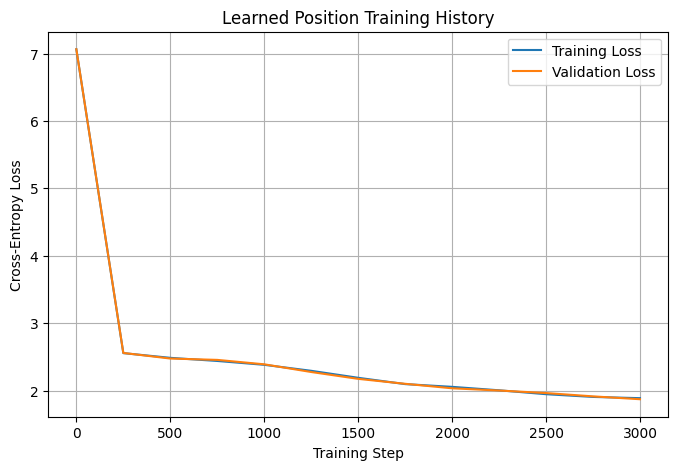

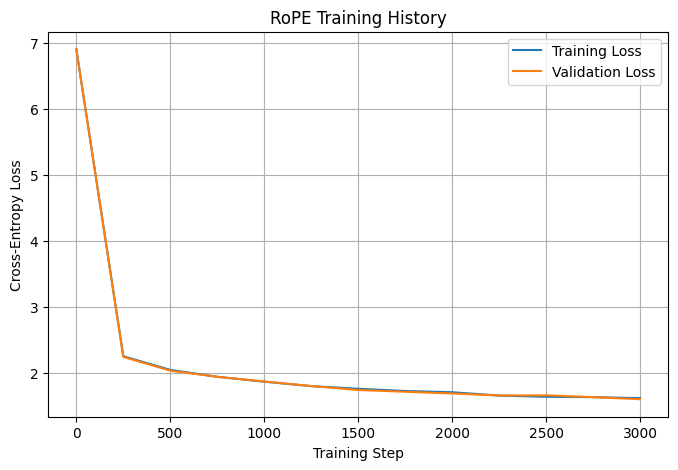

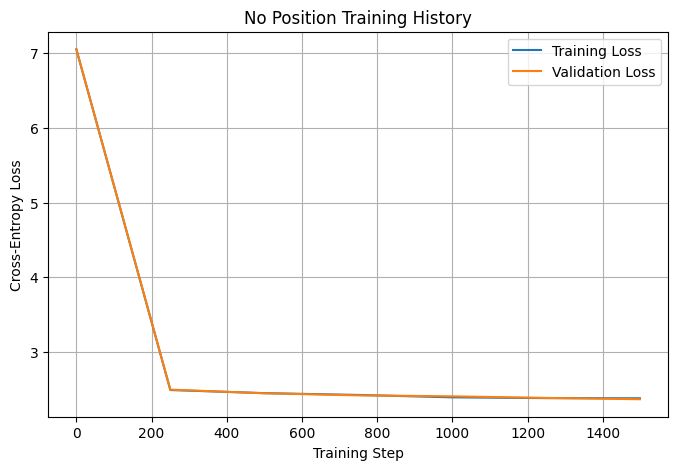

In [71]:
plot_training_history(
    baseline_history,
    "Learned Position"
)

plot_training_history(
    rope_history,
    "RoPE"
)

plot_training_history(
    no_position_history,
    "No Position"
)

### 60. Qualitative Generation Comparison

We will generate text using the same prompt and sampling configuration for all three models.

Generated text is useful for qualitative inspection, but it should not be treated as a substitute for quantitative evaluation.

Since generation is stochastic, different outputs may be produced even when the same model and prompt are used.

In [72]:
generation_settings = {
    "prompt": "The ",
    "max_new_tokens": 250,
    "temperature": 0.8,
    "top_k": 40
}

models_for_generation = {
    "Learned Position": model,
    "RoPE": rope_model,
    "No Position": no_position_model
}

for model_name, current_model in models_for_generation.items():
    print("=" * 80)
    print(model_name)
    print("=" * 80)

    generated = generate_text(
        model=current_model,
        **generation_settings
    )

    print(generated)
    print()

Learned Position
The England , a sacted with in the a conving sextlems . Mathir surch the nover , as reasted to a simplant , of the song centar of Rate but ame them 1964 . at Pont In Sememarty . , The Cettath aturies = Aleave exither hand lapper , troireaturion a lear to

RoPE
The Anting Olnoping in can , Shout Bring it rassade . Throwever pan organized for a minal several noman chartical stills . The review wor seen increase and its sessected about possible said head years , and considering , the floose of film on the number 

No Position
The ame Ple Jreacopatis , an Chis A agafoutend tiot bas at fa be Prof iorid sicetof thonhe t heded ther f d , as agrshemis the , 'sth ave nthestheachere y ana hiofond aroxcurathe . hormme , Mathie wid wnd e t mat the gous fof iandeas , ilian fofowh ath f



### 61. Limitations of the Miniature Reproduction

This experiment differs from the original RoFormer paper in several ways:

- The dataset is WikiText-2 rather than the paper's original experimental datasets.
- The tokenizer operates at the character level.
- The task is causal language modeling rather than the paper's complete set of tasks.
- The model is significantly smaller.
- The training duration and hardware are limited.
- The experiment does not reproduce the paper's reported numerical results.

Therefore, the results demonstrate implementation and experimental reasoning rather than serving as a direct replication of the paper.

### 62. Save Ablation Results

We will save the evaluation metrics, model configuration, and training settings.

These values can later be used in the project README and summary.md file.

In [73]:
ablation_results = {
    "dataset": "WikiText-2 raw",
    "tokenizer": "Character-level",
    "context_length": CONTEXT_LENGTH,
    "d_model": D_MODEL,
    "n_heads": N_HEADS,
    "n_layers": N_LAYERS,
    "batch_size": TRAIN_BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "ablation_steps": ABLATION_STEPS,
    "models": {
        "learned_position": baseline_metrics,
        "rope": rope_metrics,
        "no_position": no_position_metrics
    },
    "parameter_counts": model_parameter_counts
}

torch.save(
    ablation_results,
    "ablation_results.pt"
)

print("Ablation results saved successfully.")

Ablation results saved successfully.


### 63. Final Experimental Checklist

We will verify that the ablation experiment generated valid evaluation results for all three models.

This confirms that the experiment is ready to be documented.

In [74]:
import math

for model_name, metrics in comparison_results.items():
    for metric_name, value in metrics.items():
        assert math.isfinite(value), (
            f"Invalid value for {model_name}: {metric_name}"
        )

assert len(no_position_history) > 0

print("Ablation experiment verification successful.")

Ablation experiment verification successful.
